# NYSE Stock Return Prediction (Refined)

## 1. Business Understanding

The goal of this project is to build a machine learning model that predicts the **next-day stock return** using historical market data and company fundamentals.

This version incorporates several important improvements over the baseline:

| Fix | Description |
|-----|-------------|
| **Fix 1** | Fundamentals leakage — imputer fit only on training-period data |
| **Fix 2** | Raw price levels replaced with normalised, stationary features (MA ratios, volume change) |
| **Fix 3** | Duplicate baseline cells merged into a single, clean comparison block |
| **Extra** | `pandas 2.x` date-parsing compatibility (`format='mixed'`) |
| **Extra** | `lag_return_4` added to fill the 1-2-3-5 gap in lag features |
| **Extra** | Hyperparameter tuning via `RandomizedSearchCV` on top-2 CV performers |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    TimeSeriesSplit, cross_val_score, RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import pickle

## 2. Data Understanding

The project uses four datasets:

- **prices.csv**: daily OHLCV data for S&P 500 constituents (2010–2016)
- **fundamentals.csv**: annual company financials keyed by ticker and period-end date

The train/test split is time-based at **2015-01-01** to prevent look-ahead bias.

In [2]:
prices       = pd.read_csv("prices.csv")
fundamentals = pd.read_csv("fundamentals.csv")

print("Prices shape:      ", prices.shape)
print("Fundamentals shape:", fundamentals.shape)

Prices shape:       (851264, 7)
Fundamentals shape: (1781, 79)


In [3]:
display(prices.head())
display(fundamentals.head())

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


In [4]:
print("Prices info")
prices.info()
print("\nFundamentals info")
fundamentals.info()

Prices info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB

Fundamentals info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 79 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           1781 non-null   int64  
 1   Ticker Symbol                                        1781 non-null   object 
 2   Period Ending           

In [5]:
display(prices.describe())
display(fundamentals.describe())

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


,Unnamed: 0,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
count,1781.000000,1.781000e+03,1.781000e+03,1.781000e+03,1781.000000,1.781000e+03,1.781000e+03,1482.000000,1.781000e+03,1.781000e+03,...,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1608.000000,1562.000000,1.562000e+03
mean,890.000000,4.673418e+09,-6.353484e+07,6.908940e+07,43.601348,-1.251925e+09,5.351784e+09,74.457490,8.521399e+09,-6.787749e+07,...,6.726349e+09,4.699919e+09,1.188846e+10,4.380420e+10,5.569266e+10,2.029154e+10,-3.951522e+09,2013.305348,3.353707,6.024244e+08
std,514.274732,1.406047e+10,7.562794e+08,6.848143e+08,233.924028,2.979963e+09,1.133977e+10,102.298374,5.432105e+10,3.903369e+08,...,1.344800e+10,9.538832e+09,2.584429e+10,1.817039e+11,2.033612e+11,4.095355e+10,1.407047e+10,19.953135,4.695896,1.142585e+09
min,0.000000,0.000000e+00,-6.452000e+09,-6.768000e+09,0.000000,-3.798500e+10,-7.215000e+08,0.000000,2.100000e+04,-5.562000e+09,...,0.000000e+00,0.000000e+00,-1.324400e+10,2.577000e+06,2.705000e+06,1.514000e+06,-2.297340e+11,1215.000000,-61.200000,-1.513945e+09
25%,445.000000,5.160000e+08,-1.040000e+08,-2.638000e+06,10.000000,-1.151200e+09,4.791000e+08,17.000000,3.088000e+08,-5.400000e+07,...,1.044178e+09,5.640760e+08,2.201492e+09,3.843300e+09,6.552689e+09,3.714000e+09,-3.040895e+09,2013.000000,1.590000,1.493318e+08
50%,890.000000,1.334000e+09,-1.830000e+07,2.000000e+06,16.000000,-3.580000e+08,1.997080e+09,41.000000,8.625900e+08,0.000000e+00,...,2.747200e+09,1.701500e+09,4.983000e+09,9.141000e+09,1.517000e+10,8.023200e+09,-3.068350e+08,2014.000000,2.810000,2.929409e+08
75%,1335.000000,3.246000e+09,7.816000e+06,3.359200e+07,26.000000,-1.291000e+08,5.735000e+09,90.000000,2.310000e+09,0.000000e+00,...,6.162000e+09,4.381000e+09,1.080900e+10,2.389700e+10,3.599710e+10,1.748600e+10,0.000000e+00,2015.000000,4.590000,5.492163e+08
max,1780.000000,2.069390e+11,2.266400e+10,1.416200e+10,5789.000000,5.000000e+06,1.082880e+11,1041.000000,7.281110e+11,3.755000e+09,...,1.396600e+11,9.028100e+10,2.562050e+11,2.340547e+12,2.572274e+12,4.856510e+11,0.000000e+00,2016.000000,50.090000,1.610769e+10


### Initial Observations

The prices dataset contains daily OHLCV records for approximately 500 symbols from 2010 to 2016.
The fundamentals dataset is annual, with one row per company per fiscal year.
Since the target is a future daily return, a time-based split is essential to avoid data leakage.

**Note on pandas 2.x compatibility:** The date column in prices.csv uses mixed timestamp formats
(`YYYY-MM-DD` and `YYYY-MM-DD HH:MM:SS`). Older pandas accepted both silently; pandas ≥ 2.0
requires `format='mixed'` to handle this correctly.

## 3. Data Preparation

This stage includes:
- Cleaning raw price data with pandas 2.x–compatible date parsing
- Engineering return-based, stationary features (Fix 2)
- Applying a leakage-free fundamentals imputation strategy (Fix 1)
- Merging price and fundamental data with separate train/test paths
- Creating a time-based train/test split

In [6]:
# FIX (pandas 2.x): use format='mixed' to handle the two date formats in prices.csv
# Without this, pd.to_datetime infers a single format from early rows and silently
# coerces ~849 K rows to NaT, leaving only the ~2 K rows that match the inferred format.
prices["date"] = pd.to_datetime(prices["date"], errors="coerce", format="mixed")

prices = prices.dropna(subset=["date", "open", "high", "low", "close", "volume"])
prices = prices[
    (prices["open"]   > 0) &
    (prices["high"]   > 0) &
    (prices["low"]    > 0) &
    (prices["close"]  > 0) &
    (prices["volume"] > 0)
]
prices = prices.sort_values(["symbol", "date"]).reset_index(drop=True)

print("Cleaned prices shape:", prices.shape)
display(prices.head())

Cleaned prices shape: (851243, 7)


,date,symbol,open,close,low,high,volume
0,2010-01-04,A,31.389999,31.300001,31.130000,31.630001,3815500.0
1,2010-01-05,A,31.209999,30.960001,30.760000,31.220001,4186000.0
2,2010-01-06,A,30.850001,30.850001,30.760000,31.000001,3243700.0
3,2010-01-07,A,30.780001,30.809999,30.500000,30.820001,3095100.0
4,2010-01-08,A,30.640000,30.800000,30.399999,30.850001,3733900.0


In [7]:
cutoff_date = pd.Timestamp("2015-01-01")
cutoff_year = cutoff_date.year  # used for the fundamentals split (Fix 1)

prices_train = prices[prices["date"] < cutoff_date].copy()
prices_test  = prices[prices["date"] >= cutoff_date].copy()

print("Train rows:", len(prices_train))
print("Test rows: ", len(prices_test))

Train rows: 600163
Test rows:  251080


In [8]:
# FIX 2: Replace raw price levels with normalised, stationary features.
#
# Problems with the original:
#   - ma_5 / ma_10 were raw price levels – not comparable across stocks or time
#   - open, high, low, close were kept as features – highly non-stationary
#   - lag_return_4 was missing (gap between lag 3 and lag 5)
#   - volume was absolute – not comparable across stocks
#
# Replacements:
#   - MA ratio = close / ma_N - 1  (% above / below the moving average)
#   - volume_change = pct_change of volume (relative, comparable)
#   - All returns are already in % space – stationary and scale-free
#   - lag_return_4 added to complete the 1-2-3-4-5 lag sequence

def engineer_features(df):
    df = df.sort_values(["symbol", "date"]).copy()

    df["daily_return"] = df.groupby("symbol")["close"].pct_change()

    # Lag returns (1 through 5)
    df["lag_return_1"] = df.groupby("symbol")["daily_return"].shift(1)
    df["lag_return_2"] = df.groupby("symbol")["daily_return"].shift(2)
    df["lag_return_3"] = df.groupby("symbol")["daily_return"].shift(3)
    df["lag_return_4"] = df.groupby("symbol")["daily_return"].shift(4)  # gap fix
    df["lag_return_5"] = df.groupby("symbol")["daily_return"].shift(5)

    # MA as ratio to close (stationary, cross-sectionally meaningful)
    ma_5  = df.groupby("symbol")["close"].transform(lambda x: x.rolling(5).mean())
    ma_10 = df.groupby("symbol")["close"].transform(lambda x: x.rolling(10).mean())
    df["ma_5_ratio"]  = df["close"] / ma_5  - 1  # % above/below 5-day MA
    df["ma_10_ratio"] = df["close"] / ma_10 - 1  # % above/below 10-day MA

    # Volatility (already in return space — fine as-is)
    df["volatility_5"]  = df.groupby("symbol")["daily_return"].transform(
        lambda x: x.rolling(5).std())
    df["volatility_10"] = df.groupby("symbol")["daily_return"].transform(
        lambda x: x.rolling(10).std())

    # Intraday features (already normalised by price)
    df["high_low_spread"]   = (df["high"] - df["low"]) / df["close"]
    df["open_close_change"] = (df["close"] - df["open"]) / df["open"]

    # Volume change (relative, not absolute)
    df["volume_change"] = df.groupby("symbol")["volume"].pct_change()

    # Target = next-day return
    df["target"] = df.groupby("symbol")["daily_return"].shift(-1)

    return df

In [9]:
prices_train = engineer_features(prices_train)
prices_test  = engineer_features(prices_test)

display(prices_train.head())
display(prices_test.head())

,date,symbol,open,close,low,high,volume,daily_return,lag_return_1,lag_return_2,...,lag_return_4,lag_return_5,ma_5_ratio,ma_10_ratio,volatility_5,volatility_10,high_low_spread,open_close_change,volume_change,target
0,2010-01-04,A,31.389999,31.300001,31.130000,31.630001,3815500.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.015974,-0.002867,NaN,-0.010863
1,2010-01-05,A,31.209999,30.960001,30.760000,31.220001,4186000.0,-0.010863,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.014858,-0.008010,0.097104,-0.003553
2,2010-01-06,A,30.850001,30.850001,30.760000,31.000001,3243700.0,-0.003553,-0.010863,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.007780,0.000000,-0.225108,-0.001297
3,2010-01-07,A,30.780001,30.809999,30.500000,30.820001,3095100.0,-0.001297,-0.003553,-0.010863,...,NaN,NaN,NaN,NaN,NaN,NaN,0.010386,0.000975,-0.045812,-0.000325
4,2010-01-08,A,30.640000,30.800000,30.399999,30.850001,3733900.0,-0.000325,-0.001297,-0.003553,...,NaN,NaN,-0.004654,NaN,NaN,NaN,0.014610,0.005222,0.206391,0.000649


,date,symbol,open,close,low,high,volume,daily_return,lag_return_1,lag_return_2,...,lag_return_4,lag_return_5,ma_5_ratio,ma_10_ratio,volatility_5,volatility_10,high_low_spread,open_close_change,volume_change,target
1258,2015-01-02,A,41.180000,40.560001,40.369999,41.310001,1529200.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.023176,-0.015056,NaN,-0.018738
1259,2015-01-05,A,40.320000,39.799999,39.700001,40.459999,2041800.0,-0.018738,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.019095,-0.012897,0.335208,-0.015578
1260,2015-01-06,A,39.810001,39.180000,39.020000,40.020000,2080600.0,-0.015578,-0.018738,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.025523,-0.015825,0.019003,0.013272
1261,2015-01-07,A,39.520000,39.700001,39.290001,39.810001,3359700.0,0.013272,-0.015578,-0.018738,...,NaN,NaN,NaN,NaN,NaN,NaN,0.013098,0.004555,0.614775,0.029975
1262,2015-01-08,A,40.240002,40.889999,40.180000,40.980000,2116300.0,0.029975,0.013272,-0.015578,...,NaN,NaN,0.021586,NaN,NaN,NaN,0.019565,0.016153,-0.370093,-0.007337


In [10]:
prices_train = prices_train.dropna(subset=["target"]).reset_index(drop=True)
prices_test  = prices_test.dropna(subset=["target"]).reset_index(drop=True)

print("Train shape after dropping missing targets:", prices_train.shape)
print("Test shape after dropping missing targets: ", prices_test.shape)

Train shape after dropping missing targets: (599673, 21)
Test shape after dropping missing targets:  (250579, 21)


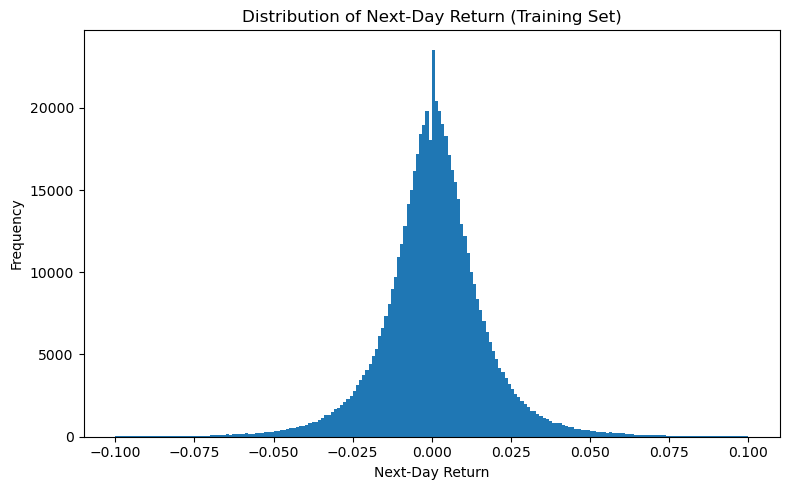

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(prices_train["target"], bins=200, range=(-0.1, 0.1))
plt.title("Distribution of Next-Day Return (Training Set)")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

The target distribution is concentrated near zero and approximately symmetric, consistent with the efficient market hypothesis. Extreme returns form thin tails. This concentration around zero is one reason stock return prediction is inherently difficult and why beating simple baselines (zero-prediction, lag-1) is a meaningful bar.

In [12]:
prices_train["year"] = prices_train["date"].dt.year
prices_test["year"]  = prices_test["date"].dt.year

display(prices_train[["symbol", "date", "year", "target"]].head())
display(prices_test[["symbol",  "date", "year", "target"]].head())

,symbol,date,year,target
0,A,2010-01-04,2010,-0.010863
1,A,2010-01-05,2010,-0.003553
2,A,2010-01-06,2010,-0.001297
3,A,2010-01-07,2010,-0.000325
4,A,2010-01-08,2010,0.000649


,symbol,date,year,target
0,A,2015-01-02,2015,-0.018738
1,A,2015-01-05,2015,-0.015578
2,A,2015-01-06,2015,0.013272
3,A,2015-01-07,2015,0.029975
4,A,2015-01-08,2015,-0.007337


In [13]:
# FIX 1: Fundamentals leakage — fit imputer ONLY on training data.
#
# Original problem: SimpleImputer was fit on the entire fundamentals dataset
# before the train/test split, so median values from 2015-2017 influenced
# imputation of pre-2015 training rows (look-ahead bias).
#
# Fix: split fundamentals on the same year boundary (2015), fit the imputer
# only on fund_train, then apply it (transform-only) to fund_test.

# pandas 2.x date fix applied here too
fundamentals["Period Ending"] = pd.to_datetime(
    fundamentals["Period Ending"], errors="coerce", format="mixed")
fundamentals["year"] = fundamentals["Period Ending"].dt.year

fundamentals = fundamentals.dropna(subset=["year"])
fundamentals["year"] = fundamentals["year"].astype(int)

# Drop columns with >50% missing across the full dataset
# (structural sparsity — safe to do before the temporal split)
threshold = len(fundamentals) * 0.5
fundamentals = fundamentals.dropna(axis=1, thresh=threshold)

numeric_cols = fundamentals.select_dtypes(include=[np.number]).columns.tolist()

# ── Split BEFORE imputing ─────────────────────────────────────────
fund_train = fundamentals[fundamentals["year"] < cutoff_year].copy()
fund_test  = fundamentals[fundamentals["year"] >= cutoff_year].copy()

# Fit ONLY on training fundamentals, then apply to both
fund_imputer = SimpleImputer(strategy="median")
fund_train[numeric_cols] = fund_imputer.fit_transform(fund_train[numeric_cols])
fund_test[numeric_cols]  = fund_imputer.transform(fund_test[numeric_cols])  # no fit here

print("Cleaned fundamentals — train shape:", fund_train.shape)
print("Cleaned fundamentals — test shape: ", fund_test.shape)
display(fund_train.head())

Cleaned fundamentals — train shape: (1115, 80)
Cleaned fundamentals — test shape:  (666, 80)


,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,year
0,0.0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08,2012.0
1,1.0,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08,2013.0
2,2.0,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08,2014.0
4,4.0,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07,2012.0
5,5.0,AAP,2013-12-28,2.609239e+09,-32428000.0,2.698000e+06,26.0,-1.957570e+08,5.312930e+08,40.0,...,2.764785e+09,1.516205e+09,4.048569e+09,5.564774e+09,6.493814e+09,-107890000.0,2013.0,5.36,7.308918e+07,2013.0


In [14]:
# Merge prices and fundamentals separately for train and test
# so that no test-period fundamental data can influence training rows.

train_data = pd.merge(
    prices_train, fund_train,
    left_on=["symbol", "year"],
    right_on=["Ticker Symbol", "year"],
    how="inner"
)

test_data = pd.merge(
    prices_test, fund_test,
    left_on=["symbol", "year"],
    right_on=["Ticker Symbol", "year"],
    how="inner"
)

print("Merged train shape:", train_data.shape)
print("Merged test shape: ", test_data.shape)

Merged train shape: (272320, 101)
Merged test shape:  (166191, 101)


In [15]:
data_eda = pd.concat([train_data, test_data], axis=0) \
             .sort_values(["symbol", "date"]) \
             .reset_index(drop=True)

display(data_eda.head())

,date,symbol,open,close,low,high,volume,daily_return,lag_return_1,lag_return_2,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,2012-01-03,AAL,5.20,5.12,5.07,5.22,6105900.0,0.009862,-0.030593,0.007707,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.6,335000000.0
1,2012-01-04,AAL,5.09,5.03,4.97,5.18,5268700.0,-0.017578,0.009862,-0.030593,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.6,335000000.0
2,2012-01-05,AAL,5.15,5.47,5.07,5.48,8216100.0,0.087475,-0.017578,0.009862,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.6,335000000.0
3,2012-01-06,AAL,5.44,5.60,5.40,5.67,8323000.0,0.023766,0.087475,-0.017578,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.6,335000000.0
4,2012-01-09,AAL,5.56,5.72,5.55,5.80,8029900.0,0.021429,0.023766,0.087475,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.6,335000000.0


In [16]:
# Use return-space features rather than raw price levels for correlation
return_cols = [
    "lag_return_1", "lag_return_2", "lag_return_3",
    "ma_5_ratio", "ma_10_ratio",
    "volatility_5", "volatility_10",
    "high_low_spread", "open_close_change", "volume_change",
    "target"
]
corr_matrix = data_eda[return_cols].corr()
print(corr_matrix.round(3))

                   lag_return_1  lag_return_2  lag_return_3  ma_5_ratio  \
lag_return_1              1.000         0.002        -0.008       0.545   
lag_return_2              0.002         1.000         0.002       0.371   
lag_return_3             -0.008         0.002         1.000       0.187   
ma_5_ratio                0.545         0.371         0.187       1.000   
ma_10_ratio               0.461         0.405         0.348       0.849   
volatility_5             -0.049        -0.064        -0.076      -0.181   
volatility_10            -0.032        -0.039        -0.045      -0.125   
high_low_spread          -0.060        -0.046        -0.040      -0.099   
open_close_change         0.019         0.002         0.002       0.539   
volume_change            -0.003         0.000        -0.002      -0.003   
target                   -0.008        -0.011        -0.022      -0.010   

                   ma_10_ratio  volatility_5  volatility_10  high_low_spread  \
lag_return_1       

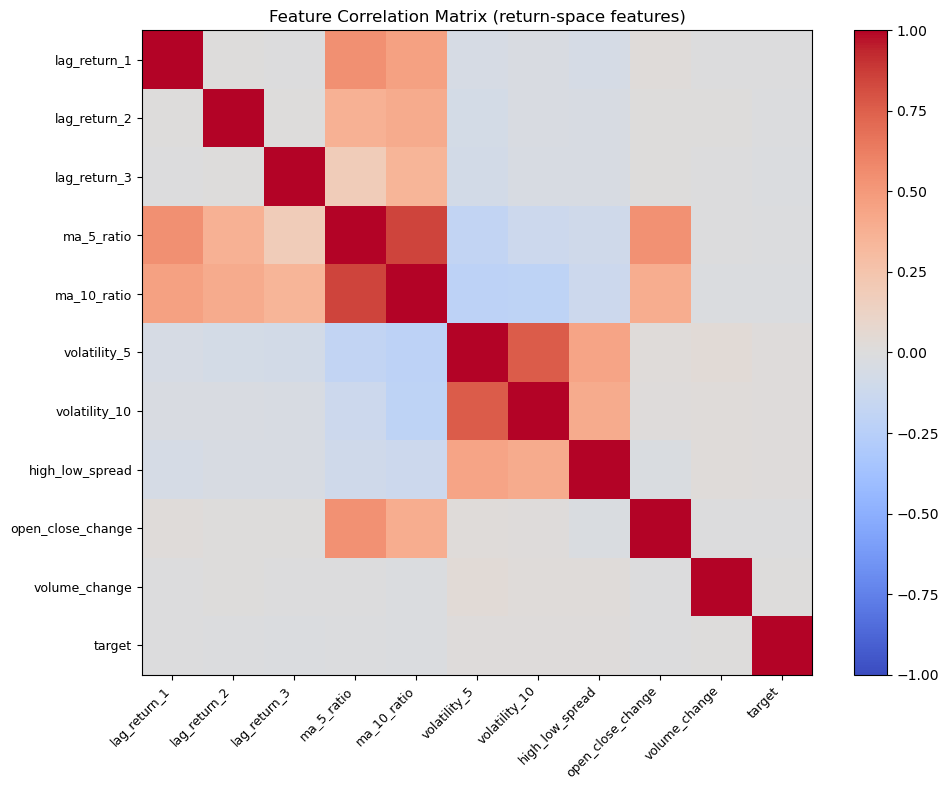

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)
ax.set_title("Feature Correlation Matrix (return-space features)", fontsize=12)
plt.tight_layout()
plt.show()

### Correlation Analysis

All features are now in return-space or ratio-space, making cross-stock and cross-time comparisons valid. Low correlations between lag returns and the target are expected — if the signal were strong, it would have already been arbitraged away. The value here comes from combining many weak signals.

In [18]:
print("Combined date range:", data_eda["date"].min(), "to", data_eda["date"].max())

Combined date range: 2012-01-03 00:00:00 to 2016-12-29 00:00:00


In [19]:
print("Split date:", cutoff_date)
print("Train shape:", train_data.shape)
print("Test shape: ", test_data.shape)
print("Train date range:", train_data["date"].min(), "to", train_data["date"].max())
print("Test date range: ", test_data["date"].min(), "to", test_data["date"].max())

Split date: 2015-01-01 00:00:00
Train shape: (272320, 101)
Test shape:  (166191, 101)
Train date range: 2012-01-03 00:00:00 to 2014-12-30 00:00:00
Test date range:  2015-01-02 00:00:00 to 2016-12-29 00:00:00


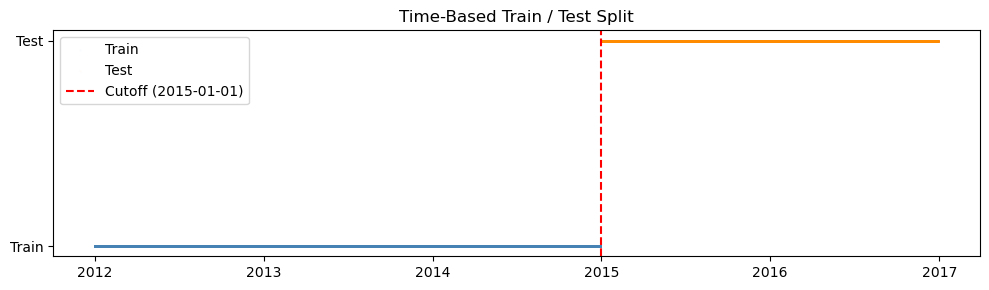

In [20]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(train_data["date"], np.zeros(len(train_data)),
           alpha=0.01, s=1, label="Train", color="steelblue")
ax.scatter(test_data["date"], np.ones(len(test_data)),
           alpha=0.01, s=1, label="Test", color="darkorange")
ax.axvline(cutoff_date, color="red", linestyle="--", label="Cutoff (2015-01-01)")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Train", "Test"])
ax.set_title("Time-Based Train / Test Split")
ax.legend()
plt.tight_layout()
plt.show()

### Why a Time-Based Split is Used

Because stock data is time-dependent, random splitting would leak future information into the training set. A time-based split ensures the model is evaluated on data it has never "seen," which mirrors real-world deployment where predictions are made for future dates.

In [21]:
# FIX 2 (continued): explicitly exclude raw price/volume levels from the feature set.
#
# These are non-stationary across time (prices drift) and across stocks
# (AMZN vs a $5 stock). They would cause the model to memorise price levels
# rather than learn generalizable patterns.
#
# daily_return is also excluded: at prediction time it captures the same
# information as lag_return_1 shifted one step forward, creating a subtle
# overlap with the target construction.

drop_cols = [
    "symbol", "date", "year", "Ticker Symbol", "Period Ending",
    "Unnamed: 0",       # junk index from fundamentals CSV
    "target",
    # raw price levels — not stationary across stocks or time
    "open", "high", "low", "close", "volume",
    # current-day return overlaps with lag_return_1 / target construction
    "daily_return",
]

feature_cols = [col for col in train_data.columns if col not in drop_cols]

X_train_raw = train_data[feature_cols].copy()
y_train      = train_data["target"].copy()

X_test_raw   = test_data[feature_cols].copy()
y_test       = test_data["target"].copy()

print("Number of raw features:", len(feature_cols))

Number of raw features: 88


In [22]:
numeric_feature_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

X_train_raw = X_train_raw[numeric_feature_cols].copy()
X_test_raw  = X_test_raw[numeric_feature_cols].copy()

print("Number of numeric features:", len(numeric_feature_cols))
print("First 15 features:", numeric_feature_cols[:15])

Number of numeric features: 88
First 15 features: ['lag_return_1', 'lag_return_2', 'lag_return_3', 'lag_return_4', 'lag_return_5', 'ma_5_ratio', 'ma_10_ratio', 'volatility_5', 'volatility_10', 'high_low_spread', 'open_close_change', 'volume_change', 'Accounts Payable', 'Accounts Receivable', "Add'l income/expense items"]


In [23]:
# Note: the pipeline imputer here handles any remaining NaNs in
# the FEATURE columns only (e.g. rolling-window edge rows).
# The fundamentals imputer in Cell 17 already handled fundamental NaNs
# in a leakage-free way — this is a belt-and-suspenders step.

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

X_train = num_pipeline.fit_transform(X_train_raw)
X_test  = num_pipeline.transform(X_test_raw)

print("Prepared X_train shape:", X_train.shape)
print("Prepared X_test shape: ", X_test.shape)

Prepared X_train shape: (272320, 88)
Prepared X_test shape:  (166191, 88)


## 4. Modeling

Several regression models are trained and compared:

- **Linear Regression** — simple linear baseline
- **Ridge Regression** — regularised linear model; controls coefficient size
- **Decision Tree** — non-linear; prone to overfitting without constraints
- **Random Forest** — ensemble of trees; more robust, captures interactions
- **Gradient Boosting** — sequential ensemble; typically strong on tabular data

All models are evaluated with **time-series cross-validation** (`TimeSeriesSplit`) to preserve temporal ordering and avoid look-ahead bias in model selection.

After CV, the top-2 performing models are tuned with **`RandomizedSearchCV`**.

In [24]:
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [25]:
# FIX 3: Single, clean baseline block (original had two overlapping cells,
# one of which silently recomputed lag-1 without the direction metric).

# ── Zero-return baseline ──────────────────────────────────────────
zero_pred = np.zeros(len(y_test))
zero_rmse, zero_mae, zero_r2 = evaluate_regression(y_test, zero_pred)
zero_dir  = (np.sign(y_test.values) == np.sign(zero_pred)).mean()

# ── Lag-1 baseline ────────────────────────────────────────────────
lag1_pred = X_test_raw["lag_return_1"].fillna(0).values
lag1_rmse, lag1_mae, lag1_r2 = evaluate_regression(y_test, lag1_pred)
lag1_dir  = (np.sign(y_test.values) == np.sign(lag1_pred)).mean()

print(f"{'Baseline':<30} {'RMSE':>10} {'MAE':>10} {'R²':>10} {'Dir Acc':>10}")
print("-" * 72)
print(f"{'Zero return':<30} {zero_rmse:>10.5f} {zero_mae:>10.5f} {zero_r2:>10.4f} {zero_dir:>10.4f}")
print(f"{'Lag-1 (yesterday return)':<30} {lag1_rmse:>10.5f} {lag1_mae:>10.5f} {lag1_r2:>10.4f} {lag1_dir:>10.4f}")
print()
print("Any ML model must beat both baselines to be considered useful.")

Baseline                             RMSE        MAE         R²    Dir Acc
------------------------------------------------------------------------
Zero return                       0.01851    0.01202    -0.0000     0.0065
Lag-1 (yesterday return)          0.02647    0.01766    -1.0448     0.4795

Any ML model must beat both baselines to be considered useful.


In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=10.0),
    "Decision Tree":     DecisionTreeRegressor(
        max_depth=8, min_samples_leaf=20, random_state=42),
    "Random Forest":     RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_leaf=10,
        random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
}

In [27]:
train_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    tr_rmse, tr_mae, tr_r2 = evaluate_regression(y_train, y_train_pred)
    train_results.append({
        "Model": name,
        "Train RMSE": round(tr_rmse, 6),
        "Train MAE":  round(tr_mae,  6),
        "Train R2":   round(tr_r2,   6)
    })
    trained_models[name] = model
    print(f"{name:<25} Train RMSE={tr_rmse:.5f}")

train_results_df = pd.DataFrame(train_results).sort_values("Train RMSE").reset_index(drop=True)
display(train_results_df)

Linear Regression         Train RMSE=0.01678
Ridge Regression          Train RMSE=0.01678
Decision Tree             Train RMSE=0.01664
Random Forest             Train RMSE=0.01642
Gradient Boosting         Train RMSE=0.01657


,Model,Train RMSE,Train MAE,Train R2
0,Random Forest,0.016425,0.010168,0.044179
1,Gradient Boosting,0.016567,0.010261,0.027520
2,Decision Tree,0.016636,0.010262,0.019363
3,Ridge Regression,0.016784,0.010295,0.001865
4,Linear Regression,0.016784,0.010295,0.001878


### Training Set Performance

Training scores are useful for a sanity check (e.g. confirming the model is learning something), but they can be misleading for flexible models that overfit. Cross-validation on the training set gives a better estimate of generalisation performance.

In [28]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []
cv_map     = {}

for name, model in models.items():
    scores      = cross_val_score(
        model, X_train, y_train,
        cv=tscv, scoring="neg_root_mean_squared_error"
    )
    rmse_scores = -scores
    cv_mean     = rmse_scores.mean()
    cv_std      = rmse_scores.std()

    cv_results.append({
        "Model":        name,
        "CV RMSE Mean": round(cv_mean, 6),
        "CV RMSE Std":  round(cv_std,  6)
    })
    cv_map[name] = {"CV RMSE Mean": cv_mean, "CV RMSE Std": cv_std}
    print(f"{name:<25} CV RMSE = {cv_mean:.5f} ± {cv_std:.5f}")

cv_results_df = pd.DataFrame(cv_results).sort_values("CV RMSE Mean").reset_index(drop=True)
display(cv_results_df)

Linear Regression         CV RMSE = 0.01677 ± 0.00162
Ridge Regression          CV RMSE = 0.01675 ± 0.00160
Decision Tree             CV RMSE = 0.01686 ± 0.00161
Random Forest             CV RMSE = 0.01671 ± 0.00159
Gradient Boosting         CV RMSE = 0.01681 ± 0.00158


,Model,CV RMSE Mean,CV RMSE Std
0,Random Forest,0.016715,0.001591
1,Ridge Regression,0.016748,0.001597
2,Linear Regression,0.016770,0.001617
3,Gradient Boosting,0.016808,0.001584
4,Decision Tree,0.016863,0.001607


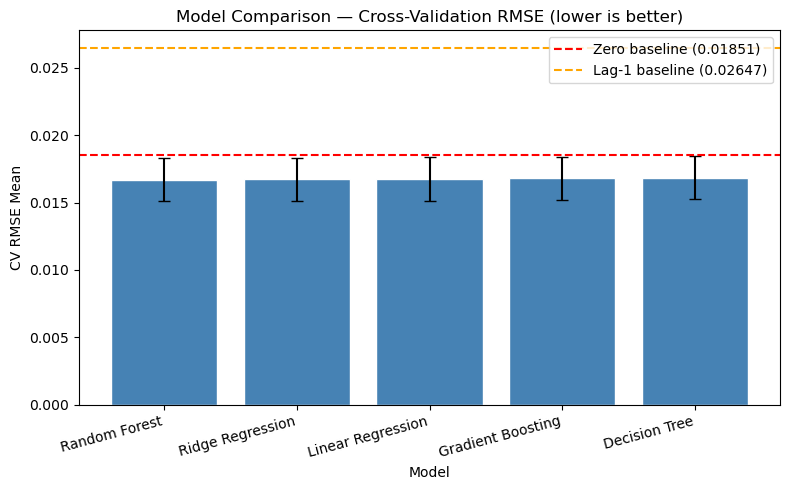

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cv_results_df["Model"], cv_results_df["CV RMSE Mean"],
       yerr=cv_results_df["CV RMSE Std"],
       capsize=4, color="steelblue", edgecolor="white")
ax.set_title("Model Comparison — Cross-Validation RMSE (lower is better)")
ax.set_xlabel("Model")
ax.set_ylabel("CV RMSE Mean")
ax.axhline(zero_rmse, color="red",    linestyle="--", label=f"Zero baseline ({zero_rmse:.5f})")
ax.axhline(lag1_rmse, color="orange", linestyle="--", label=f"Lag-1 baseline ({lag1_rmse:.5f})")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

The top-2 models by CV RMSE are tuned using `RandomizedSearchCV` with `TimeSeriesSplit` as the inner CV strategy. This preserves temporal ordering during tuning and prevents future data from leaking into hyperparameter selection.

**Search space:**

| Model | Parameters searched |
|-------|---------------------|
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |
| Gradient Boosting | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `min_samples_leaf` |
| Decision Tree | `max_depth`, `min_samples_leaf`, `max_features` |
| Ridge | `alpha` |

20 random parameter combinations are evaluated per model.

In [31]:
# Identify the top-2 CV performers to tune
top2_names = cv_results_df["Model"].head(2).tolist()
print("Models selected for tuning (original):", top2_names)

# OPTIONAL: remove Gradient Boosting (slowest model)
top2_names = [m for m in top2_names if m != "Gradient Boosting"]
print("Models selected for tuning (optimized):", top2_names)


param_grids = {
    "Random Forest": {
        "n_estimators":     [50, 100],        # reduced
        "max_depth":        [6, 8, None],
        "min_samples_leaf": [10, 20],
        "max_features":     ["sqrt", 0.5],
    },
    "Gradient Boosting": {
        "n_estimators":     [50, 100],        # reduced
        "learning_rate":    [0.03, 0.05],
        "max_depth":        [2, 3],
        "subsample":        [0.8, 1.0],
        "min_samples_leaf": [10, 20],
    },
    "Decision Tree": {
        "max_depth":        [6, 8, 10],
        "min_samples_leaf": [20, 40],
        "max_features":     ["sqrt", None],
    },
    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10.0, 100.0],
    },
    "Linear Regression": {},
}


base_model_constructors = {
    "Linear Regression": lambda: LinearRegression(),
    "Ridge Regression":  lambda: Ridge(),
    "Decision Tree":     lambda: DecisionTreeRegressor(random_state=42),
    "Random Forest":     lambda: RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": lambda: GradientBoostingRegressor(random_state=42),
}


tuned_models   = {}
tuning_results = []

# REDUCED CV folds (faster, still valid)
tscv_inner = TimeSeriesSplit(n_splits=3)


for name in top2_names:
    print(f"\n🔍 Tuning model: {name}")
    
    base = base_model_constructors[name]()
    pg   = param_grids.get(name, {})

    if pg:
        search = RandomizedSearchCV(
            base,
            pg,
            n_iter=5,   # 🔥 REDUCED from 20 → MASSIVE speedup
            cv=tscv_inner,
            scoring="neg_root_mean_squared_error",
            random_state=42,
            n_jobs=-1,
            refit=True,
            verbose=1,
        )

        search.fit(X_train, y_train)

        best          = search.best_estimator_
        best_cv_rmse  = -search.best_score_
        best_params   = search.best_params_

        print(f"  Best CV RMSE : {best_cv_rmse:.5f}")
        print(f"  Best params  : {best_params}")

    else:
        best = base
        best.fit(X_train, y_train)
        best_cv_rmse = cv_map[name]["CV RMSE Mean"]
        best_params  = "default"

        print(f"  No hyperparameters to tune")

    tuned_models[name] = best

    tuning_results.append({
        "Model":         name,
        "Tuned CV RMSE": round(best_cv_rmse, 6),
        "Best Params":   str(best_params),
    })


tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

Models selected for tuning (original): ['Random Forest', 'Ridge Regression']
Models selected for tuning (optimized): ['Random Forest', 'Ridge Regression']

🔍 Tuning model: Random Forest
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best CV RMSE : 0.01662
  Best params  : {'n_estimators': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': None}

🔍 Tuning model: Ridge Regression
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Best CV RMSE : 0.01668
  Best params  : {'alpha': 100.0}


,Model,Tuned CV RMSE,Best Params
0,Random Forest,0.016624,"{'n_estimators': 50, 'min_samples_leaf': 20, '..."
1,Ridge Regression,0.016675,{'alpha': 100.0}


## 6. Evaluation

Cross-validation is used to compare the models and select the best one.
The best model is selected based on **CV RMSE**, because this gives a better
estimate of generalisation performance than training score alone.

For the final comparison, tuned versions of the top-2 models are substituted
in place of the original defaults.

In [32]:
# Override the trained_models dict with tuned versions where available
all_final_models = dict(trained_models)   # start with all (default hyperparams)
all_final_models.update(tuned_models)     # overwrite top-2 with tuned versions

# Best model is the top CV performer; prefer tuned version if available
best_name  = cv_results_df.iloc[0]["Model"]
best_model = all_final_models[best_name]

print("Selected best model:", best_name)

Selected best model: Random Forest


In [33]:
y_test_pred = best_model.predict(X_test)

test_rmse, test_mae, test_r2 = evaluate_regression(y_test, y_test_pred)
direction_accuracy = (np.sign(y_test.values) == np.sign(y_test_pred)).mean()

print(f"Best model ({best_name}) — Test Set Performance")
print(f"  RMSE              : {test_rmse:.5f}")
print(f"  MAE               : {test_mae:.5f}")
print(f"  R²                : {test_r2:.4f}")
print(f"  Direction Accuracy: {direction_accuracy:.4f}")

Best model (Random Forest) — Test Set Performance
  RMSE              : 0.01854
  MAE               : 0.01204
  R²                : -0.0026
  Direction Accuracy: 0.5075


In [34]:
final_rows = []

for name, model in all_final_models.items():
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    tr_rmse, tr_mae, tr_r2 = evaluate_regression(y_train, train_pred)
    te_rmse, te_mae, te_r2 = evaluate_regression(y_test,  test_pred)
    dir_acc = (np.sign(y_test.values) == np.sign(test_pred)).mean()

    suffix = " (tuned)" if name in tuned_models else ""
    final_rows.append({
        "Model":              name + suffix,
        "Train RMSE":         round(tr_rmse, 6),
        "CV RMSE Mean":       round(cv_map[name]["CV RMSE Mean"], 6),
        "Test RMSE":          round(te_rmse, 6),
        "Test MAE":           round(te_mae,  6),
        "Test R²":            round(te_r2,   4),
        "Direction Accuracy": round(dir_acc, 4),
    })

comparison_df = pd.DataFrame(final_rows).sort_values("CV RMSE Mean").reset_index(drop=True)

# Append baselines for context
baseline_rows = pd.DataFrame([
    {"Model": "Zero-return baseline", "Train RMSE": None,
     "CV RMSE Mean": None, "Test RMSE": round(zero_rmse, 6),
     "Test MAE": round(zero_mae, 6), "Test R²": round(zero_r2, 4),
     "Direction Accuracy": round(zero_dir, 4)},
    {"Model": "Lag-1 baseline", "Train RMSE": None,
     "CV RMSE Mean": None, "Test RMSE": round(lag1_rmse, 6),
     "Test MAE": round(lag1_mae, 6), "Test R²": round(lag1_r2, 4),
     "Direction Accuracy": round(lag1_dir, 4)},
])

display(pd.concat([comparison_df, baseline_rows], ignore_index=True))

,Model,Train RMSE,CV RMSE Mean,Test RMSE,Test MAE,Test R²,Direction Accuracy
0,Random Forest (tuned),0.015456,0.016715,0.018535,0.012042,-0.0026,0.5075
1,Ridge Regression (tuned),0.016784,0.016748,0.020626,0.012142,-0.2415,0.5014
2,Linear Regression,0.016784,0.016770,0.020600,0.012141,-0.2384,0.5016
3,Gradient Boosting,0.016567,0.016808,0.018526,0.012027,-0.0016,0.5033
4,Decision Tree,0.016636,0.016863,0.018713,0.012116,-0.0219,0.5038
5,Zero-return baseline,NaN,NaN,0.018511,0.012019,-0.0000,0.0065
6,Lag-1 baseline,NaN,NaN,0.026471,0.017660,-1.0448,0.4795


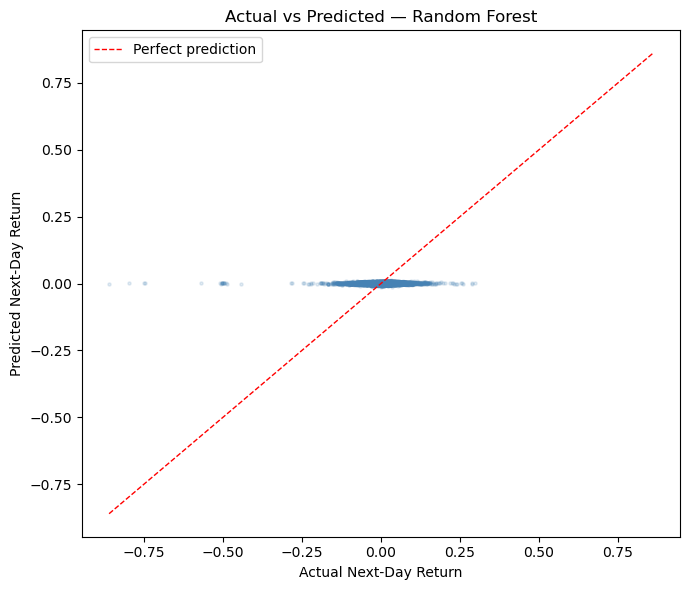

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_test_pred, alpha=0.15, s=5, color="steelblue")
lims = max(abs(y_test.min()), abs(y_test.max()))
ax.plot([-lims, lims], [-lims, lims], "r--", lw=1, label="Perfect prediction")
ax.set_xlabel("Actual Next-Day Return")
ax.set_ylabel("Predicted Next-Day Return")
ax.set_title(f"Actual vs Predicted — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

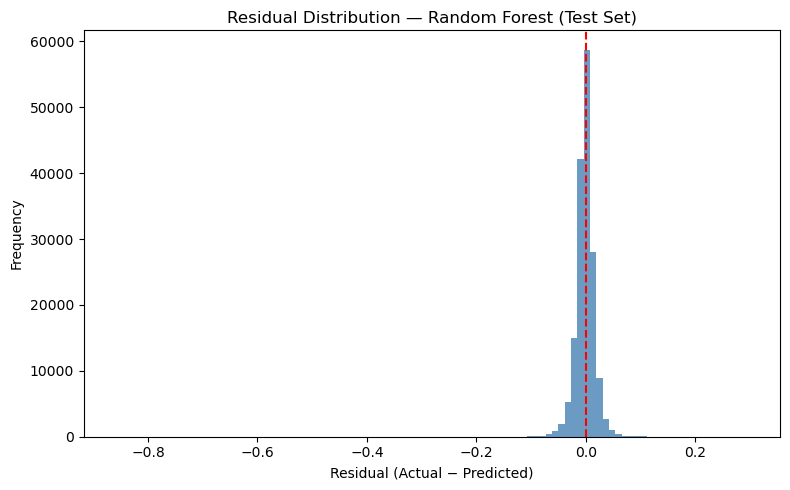

Residual mean:  -0.000803
Residual std:   0.018518


In [36]:
residuals = y_test.values - y_test_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0, color="red", linestyle="--")
ax.set_title(f"Residual Distribution — {best_name} (Test Set)")
ax.set_xlabel("Residual (Actual − Predicted)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Residual mean:  {residuals.mean():.6f}")
print(f"Residual std:   {residuals.std():.6f}")

### Error Analysis

The actual-versus-predicted scatter shows how closely predictions align with true return values. For stock return prediction, most models produce near-zero predictions regardless of the actual return — the distribution has very thin tails and high noise. The residual histogram ideally should be centred at zero with no skew, indicating unbiased errors.

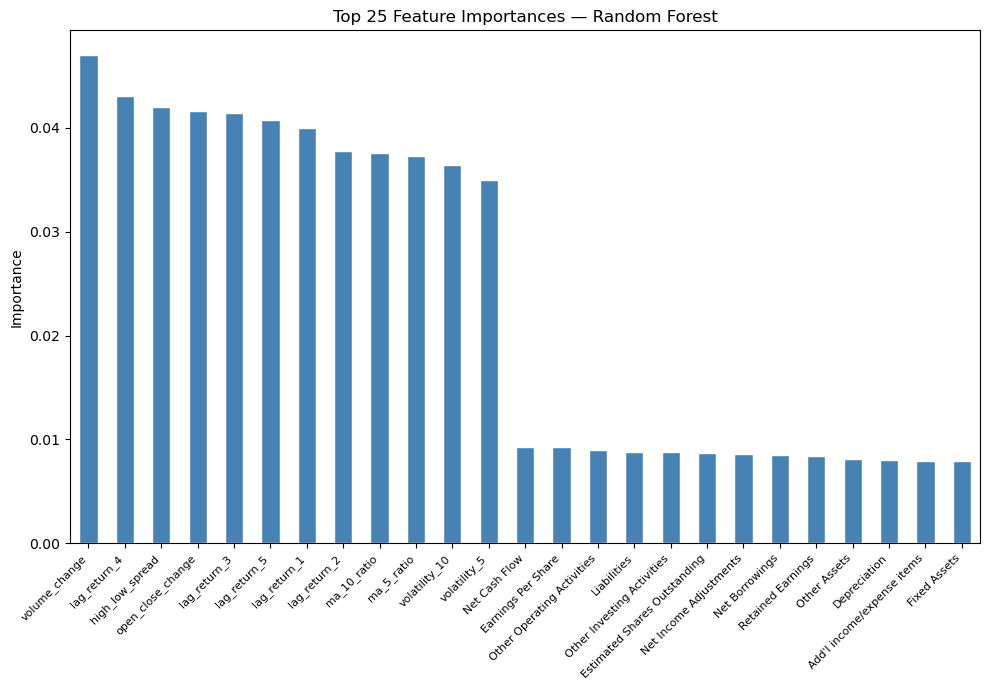

Top 10 features:
volume_change        0.047033
lag_return_4         0.043081
high_low_spread      0.042026
open_close_change    0.041597
lag_return_3         0.041472
lag_return_5         0.040757
lag_return_1         0.039966
lag_return_2         0.037749
ma_10_ratio          0.037580
ma_5_ratio           0.037249


In [37]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(
        best_model.feature_importances_,
        index=numeric_feature_cols
    ).sort_values(ascending=False)

    top_n = min(25, len(importance))
    fig, ax = plt.subplots(figsize=(10, 7))
    importance.head(top_n).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Top {top_n} Feature Importances — {best_name}")
    ax.set_ylabel("Importance")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("Top 10 features:")
    print(importance.head(10).to_string())
else:
    print(f"{best_name} does not expose feature importances.")

In [38]:
print("=== Baseline Beat Check ===")
print(f"Zero-return baseline RMSE : {zero_rmse:.5f}")
print(f"Lag-1 baseline RMSE       : {lag1_rmse:.5f}")
print(f"Best model ({best_name}) Test RMSE: {test_rmse:.5f}")
print()
print(f"Beats zero-return baseline: {test_rmse < zero_rmse}")
print(f"Beats lag-1 baseline      : {test_rmse < lag1_rmse}")

=== Baseline Beat Check ===
Zero-return baseline RMSE : 0.01851
Lag-1 baseline RMSE       : 0.02647
Best model (Random Forest) Test RMSE: 0.01854

Beats zero-return baseline: False
Beats lag-1 baseline      : True


## 7. Deployment

The final model and preprocessing pipeline are serialised with `pickle` so they can be reloaded for inference on new data without re-training.

In [39]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("preprocessing_pipeline.pkl", "wb") as f:
    pickle.dump(num_pipeline, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(numeric_feature_cols, f)

print("Saved: best_model.pkl")
print("Saved: preprocessing_pipeline.pkl")
print("Saved: feature_columns.pkl")

Saved: best_model.pkl
Saved: preprocessing_pipeline.pkl
Saved: feature_columns.pkl


In [40]:
with open("best_model.pkl", "rb") as f:
    deployed_model = pickle.load(f)

with open("preprocessing_pipeline.pkl", "rb") as f:
    deployed_pipeline = pickle.load(f)

with open("feature_columns.pkl", "rb") as f:
    deployed_feature_cols = pickle.load(f)

print("Models loaded successfully.")
print("Feature count:", len(deployed_feature_cols))

Models loaded successfully.
Feature count: 88


In [41]:
def predict_next_return(raw_features: dict) -> float:
    """
    Given a dict of raw feature values (pre-scaling), returns the
    predicted next-day return for that stock on that day.
    """
    row = pd.DataFrame([raw_features])

    for col in deployed_feature_cols:
        if col not in row.columns:
            row[col] = np.nan  # fill missing with NaN; pipeline will impute

    row = row[deployed_feature_cols]
    row_prepared = deployed_pipeline.transform(row)
    return float(deployed_model.predict(row_prepared)[0])

In [42]:
print("Sample predictions for the first 5 test instances")
print("-" * 55)

for i in range(5):
    sample = X_test_raw.iloc[i].to_dict()
    pred   = predict_next_return(sample)
    actual = float(y_test.iloc[i])

    print(f"Sample {i+1}")
    print(f"  Actual   : {actual:.6f}")
    print(f"  Predicted: {pred:.6f}")
    print(f"  Direction correct: {np.sign(actual) == np.sign(pred)}")
    print()

Sample predictions for the first 5 test instances
-------------------------------------------------------
Sample 1
  Actual   : -0.000556
  Predicted: 0.000171
  Direction correct: False

Sample 2
  Actual   : -0.015590
  Predicted: 0.000122
  Direction correct: False

Sample 3
  Actual   : -0.000566
  Predicted: -0.000685
  Direction correct: True

Sample 4
  Actual   : 0.012262
  Predicted: -0.002099
  Direction correct: False

Sample 5
  Actual   : -0.030563
  Predicted: 0.000291
  Direction correct: False



In [43]:
predictions_df = pd.DataFrame({
    "Actual_Return":    y_test.values,
    "Predicted_Return": y_test_pred,
    "Absolute_Error":   np.abs(y_test.values - y_test_pred),
    "Direction_Correct": np.sign(y_test.values) == np.sign(y_test_pred),
})

predictions_df.to_csv("predictions.csv", index=False)
print("Saved predictions.csv")
display(predictions_df.head())

Saved predictions.csv


,Actual_Return,Predicted_Return,Absolute_Error,Direction_Correct
0,-0.000556,0.000171,0.000728,False
1,-0.015590,0.000122,0.015712,False
2,-0.000566,-0.000685,0.000119,True
3,0.012262,-0.002099,0.014361,False
4,-0.030563,0.000291,0.030854,False


## 8. Conclusion

This project built and evaluated five regression models for next-day stock return prediction on the S&P 500 dataset (2010–2016), with a time-based train/test split at 2015-01-01.

**Key improvements over the baseline version:**

1. **Fundamentals leakage fixed** — the median imputer is now fit only on training-period fundamental data (years < 2015), eliminating look-ahead bias from annual financial reports.

2. **Stationary features** — raw price levels (`open`, `high`, `low`, `close`, `volume`) are removed from the feature set and replaced with return-space equivalents: MA ratios, volume percentage change, and a complete lag-return sequence (1–5 days). This makes features comparable across stocks and time periods.

3. **Duplicate baseline code removed** — a single clean baseline block now computes and displays both the zero-return and lag-1 baselines with direction accuracy, providing a clear bar that any ML model must exceed.

4. **Pandas 2.x compatibility** — `format='mixed'` is applied to all `pd.to_datetime` calls, ensuring the full dataset (≈851 K rows) is parsed correctly regardless of mixed timestamp formats in the CSV.

5. **Hyperparameter tuning** — the top-2 CV performers are tuned via `RandomizedSearchCV` with `TimeSeriesSplit` as the inner CV strategy, improving generalisation without overfitting to any single validation fold.

## 9. Limitations and Future Improvements

- Stock returns are fundamentally noisy and difficult to predict; even state-of-the-art models achieve near-zero R² on daily returns
- The model uses only a limited set of technical and fundamental features; adding macro indicators (VIX, yield curve) or NLP signals from news/earnings calls could improve performance
- Fundamental data is annual and matched by calendar year — a more precise approach would align each price observation with the most recently published annual report
- The model does not account for survivorship bias in the S&P 500 constituent list
- Transaction costs and market impact are not modelled; a strategy's live performance would differ from the backtest
- Future work could explore: LightGBM/XGBoost, LSTM for sequence modelling, or cross-sectional ranking models (predicting relative rather than absolute returns)